# 13. Probability Ranking Analysis

This notebook takes the final recommended candidate from notebook 12, fits it again on the aligned feature bundle, and inspects the **quality of its number ranking** directly. Instead of only asking whether the top-6 set looks good, we check whether the probability scores meaningfully separate positive and negative outcomes and whether top-k ranking behavior is sensible.

## Bootstrap

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
APP_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "notebook_support.py").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break
    if (candidate / "app" / "src" / "notebook_support.py").exists() and (candidate / "app" / "data").exists():
        APP_ROOT = candidate / "app"
        break

if APP_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment
describe_notebook_environment(APP_ROOT)

{'app_root': '/workspace', 'cwd': '/workspace/notebooks'}

## Imports

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import TABLES_DIR
from src.features import build_model_feature_bundle, load_weather_context
from src.features.temporal_features import time_based_train_test_split
from src.models.evaluate import compute_calibration_table, compute_precision_at_k_curve, flatten_probability_outputs
from src.models.model_suite import evaluate_number_predictions, get_probability_matrix, probability_matrix_to_number_lists
from src.visualization import save_report_figure, save_report_table

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
np.random.seed(42)

## Configuration

In [3]:
WINDOW = 20
TEST_RATIO = 0.2
RANDOM_SEED = 42
RECOMMENDATION_FILE = TABLES_DIR / "table_34_final_recommendation.csv"
OVERRIDE_CANDIDATE = None  # set to dict(feature_set=..., model=..., training_regime=...) if you want to override notebook 12

if not RECOMMENDATION_FILE.exists() and OVERRIDE_CANDIDATE is None:
    raise FileNotFoundError(f"Missing final recommendation table: {RECOMMENDATION_FILE}")

## Load Final Recommendation

In [4]:
if OVERRIDE_CANDIDATE is None:
    recommendation_df = pd.read_csv(RECOMMENDATION_FILE)
    selected = recommendation_df.iloc[0].to_dict()
else:
    selected = OVERRIDE_CANDIDATE.copy()

selected

{'feature_set': 'full_feature_set',
 'model': 'soft_voting_ensemble',
 'training_regime': 'last_500',
 'folds': 10,
 'mean_subset_accuracy': 0.0,
 'mean_number_level_accuracy': 0.7697777777777778,
 'mean_avg_hit': 0.82,
 'mean_precision_at_6': 0.1366666666666666,
 'mean_recall_at_6': 0.1366666666666666,
 'mean_brier_score': 0.192893629882203,
 'std_avg_hit': 0.0958393717904347,
 'subset_accuracy': 0.0,
 'number_level_accuracy': 0.7716920239741817,
 'avg_hit': 0.8630705394190872,
 'hit_std': 0.8261326383233074,
 'precision_at_6': 0.1438450899031812,
 'recall_at_6': 0.1438450899031812,
 'brier_score': 0.1951800749142114,
 'source_notebook': '11_recent_window_modeling',
 'candidate_label': 'soft_voting_ensemble | full_feature_set | last_500',
 'rank_backtest_hit': 18.0,
 'rank_backtest_precision': 6.0,
 'rank_backtest_brier': 18.0,
 'rank_backtest_stability': 7.0,
 'rank_holdout_hit': 15.0,
 'rank_holdout_brier': 21.0,
 'selection_score': 14.25}

## Candidate Helpers

In [5]:
def parse_training_regime(training_regime):
    if training_regime == "full_history":
        return None
    if isinstance(training_regime, str) and training_regime.startswith("last_"):
        return int(training_regime.split("_")[1])
    raise ValueError(f"Unsupported training regime: {training_regime}")


def build_model(model_name: str, random_seed: int):
    if model_name == "logistic_regression":
        return __import__("src.models.train_baseline", fromlist=["build_logistic_regression_model"]).build_logistic_regression_model(random_seed=random_seed)
    if model_name == "random_forest":
        return __import__("src.models.train_random_forest", fromlist=["build_random_forest_model"]).build_random_forest_model(random_seed=random_seed)
    if model_name == "xgboost":
        return __import__("src.models.train_xgboost", fromlist=["build_xgboost_model"]).build_xgboost_model(random_seed=random_seed)
    if model_name == "classifier_chain":
        return __import__("src.models.train_baseline", fromlist=["build_classifier_chain_model"]).build_classifier_chain_model(random_seed=random_seed)
    if model_name == "soft_voting_ensemble":
        return __import__("src.models.train_ensemble", fromlist=["build_soft_voting_ensemble_model"]).build_soft_voting_ensemble_model(random_seed=random_seed)
    if model_name == "mlp":
        return __import__("src.models.train_mlp", fromlist=["build_scaled_mlp_model"]).build_scaled_mlp_model(random_seed=random_seed)
    raise ValueError(model_name)


def apply_train_window(X_train, y_train, train_window_size):
    if train_window_size is None:
        return X_train.reset_index(drop=True), y_train.reset_index(drop=True)
    return (
        X_train.tail(train_window_size).reset_index(drop=True),
        y_train.tail(train_window_size).reset_index(drop=True),
    )

## Load Feature Bundle and Fit Selected Candidate

In [6]:
weather_df = load_weather_context()
feature_bundle = build_model_feature_bundle(window=WINDOW, save_base=False, weather_df=weather_df)
y = feature_bundle.y.reset_index(drop=True)
LABEL_COLS = y.columns.tolist()

feature_set_name = selected["feature_set"]
model_name = selected["model"]
training_regime = selected["training_regime"]
train_window_size = parse_training_regime(training_regime)

X = feature_bundle.feature_sets[feature_set_name].reset_index(drop=True)
split = time_based_train_test_split(X, y, test_ratio=TEST_RATIO)
X_train, y_train = apply_train_window(split["X_train"], split["y_train"], train_window_size)
X_test = split["X_test"].reset_index(drop=True)
y_test = split["y_test"].reset_index(drop=True)

model = build_model(model_name, random_seed=RANDOM_SEED)
model.fit(X_train, y_train)
probability_matrix = get_probability_matrix(model, X_test)
predicted_number_lists = probability_matrix_to_number_lists(probability_matrix)
holdout_eval = evaluate_number_predictions(model_name, predicted_number_lists, y_test, label_cols=LABEL_COLS, probability_matrix=probability_matrix)

pd.DataFrame([{
    "feature_set": feature_set_name,
    "model": model_name,
    "training_regime": training_regime,
    "n_train_rows": len(X_train),
    "n_test_rows": len(X_test),
    "avg_hit": holdout_eval["avg_hit"],
    "precision_at_6": holdout_eval["precision_at_6"],
    "brier_score": holdout_eval["brier_score"],
}])

,feature_set,model,training_regime,n_train_rows,n_test_rows,avg_hit,precision_at_6,brier_score
0,full_feature_set,soft_voting_ensemble,last_500,500,241,0.863071,0.143845,0.19518


## Calibration and Precision@k Diagnostics

In [7]:
calibration_table = compute_calibration_table(probability_matrix, y_test, n_bins=10)
precision_k_table = compute_precision_at_k_curve(probability_matrix, y_test, ks=tuple(range(1, 16)))
flat_probability_frame = flatten_probability_outputs(probability_matrix, y_test)
flat_probability_frame["actual_label"] = flat_probability_frame["actual"].map({0: "negative", 1: "positive"})

calibration_table.head(), precision_k_table.head(), flat_probability_frame.head()

(  probability_bin  count  mean_predicted_probability  observed_positive_rate
 0   (-0.001, 0.1]   4164                    0.051024                0.129923
 1      (0.1, 0.2]   1966                    0.141313                0.133774
 2      (0.2, 0.3]    832                    0.244453                0.117788
 3      (0.3, 0.4]    665                    0.353171                0.139850
 4      (0.4, 0.5]    754                    0.447814                0.145889,
    k  precision_at_k
 0  1        0.141079
 1  2        0.143154
 2  3        0.134163
 3  4        0.136929
 4  5        0.139419,
    predicted_probability  actual actual_label
 0               0.233529       0     negative
 1               0.144057       0     negative
 2               0.616554       0     negative
 3               0.070638       0     negative
 4               0.061780       1     positive)

## Top-Ranked Number Analysis

In [8]:
top6_df = pd.DataFrame({
    "draw_index": np.arange(len(predicted_number_lists)),
    "predicted_numbers": [",".join(map(str, nums)) for nums in predicted_number_lists],
    "hit_count": holdout_eval["draw_results"]["hit_count"].tolist(),
})

rank_positions = np.argsort(probability_matrix, axis=1)[:, ::-1] + 1
rank_df = pd.DataFrame(rank_positions[:, :10], columns=[f"rank_{i}" for i in range(1, 11)])
rank_long = rank_df.melt(var_name="rank_slot", value_name="number")
rank_frequency = rank_long.groupby(["rank_slot", "number"], as_index=False).size().rename(columns={"size": "count"})

top6_df.head(), rank_frequency.head()

(   draw_index predicted_numbers  hit_count
 0           0   3,8,12,18,22,42          0
 1           1   3,8,10,19,22,23          1
 2           2   1,8,15,18,19,22          0
 3           3    1,3,6,15,19,22          0
 4           4    1,3,4,15,19,22          0,
   rank_slot  number  count
 0    rank_1       1     14
 1    rank_1       2     18
 2    rank_1       3      1
 3    rank_1       4     14
 4    rank_1       5      1)

## Visual Diagnostics

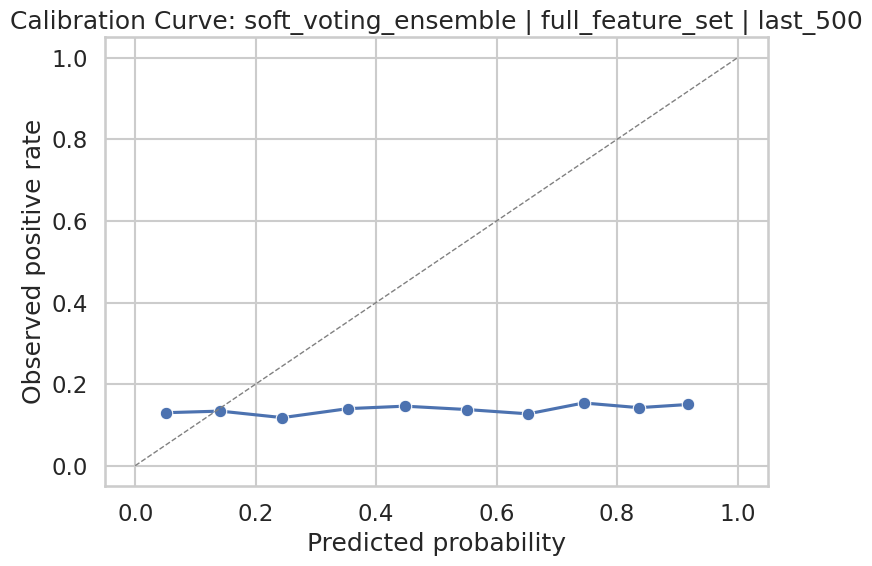

In [9]:
fig_calibration, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=calibration_table, x="mean_predicted_probability", y="observed_positive_rate", marker="o", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title(f"Calibration Curve: {model_name} | {feature_set_name} | {training_regime}")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed positive rate")
plt.tight_layout()
plt.show()

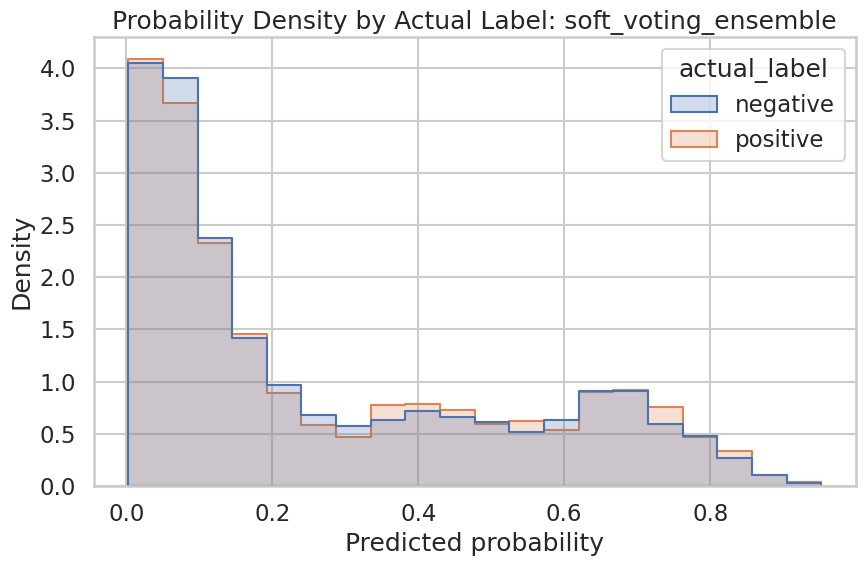

In [10]:
fig_probability_density, ax = plt.subplots(figsize=(9, 6))
sns.histplot(data=flat_probability_frame, x="predicted_probability", hue="actual_label", bins=20, stat="density", common_norm=False, element="step", ax=ax)
ax.set_title(f"Probability Density by Actual Label: {model_name}")
ax.set_xlabel("Predicted probability")
plt.tight_layout()
plt.show()

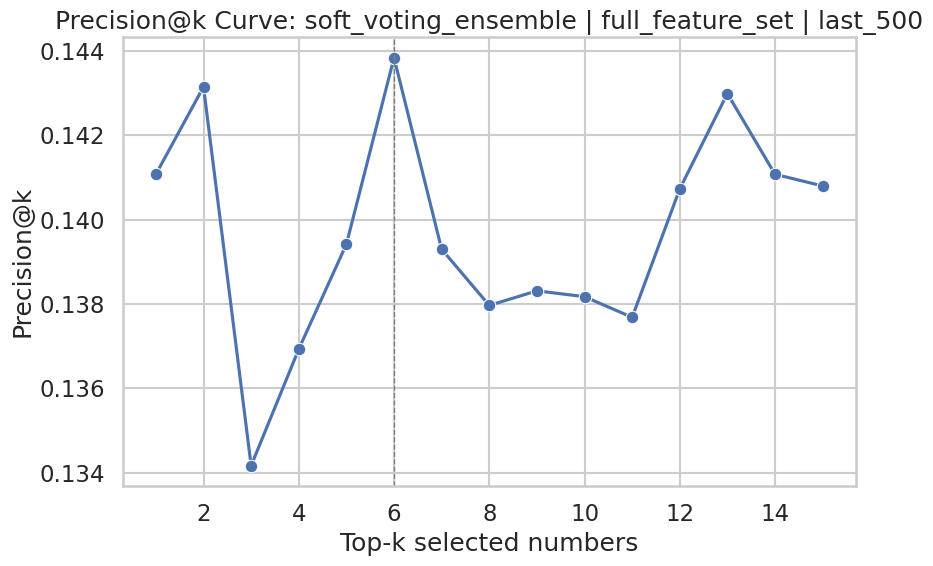

In [11]:
fig_precision_k, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(data=precision_k_table, x="k", y="precision_at_k", marker="o", ax=ax)
ax.axvline(6, linestyle="--", color="gray", linewidth=1)
ax.set_title(f"Precision@k Curve: {model_name} | {feature_set_name} | {training_regime}")
ax.set_xlabel("Top-k selected numbers")
ax.set_ylabel("Precision@k")
plt.tight_layout()
plt.show()

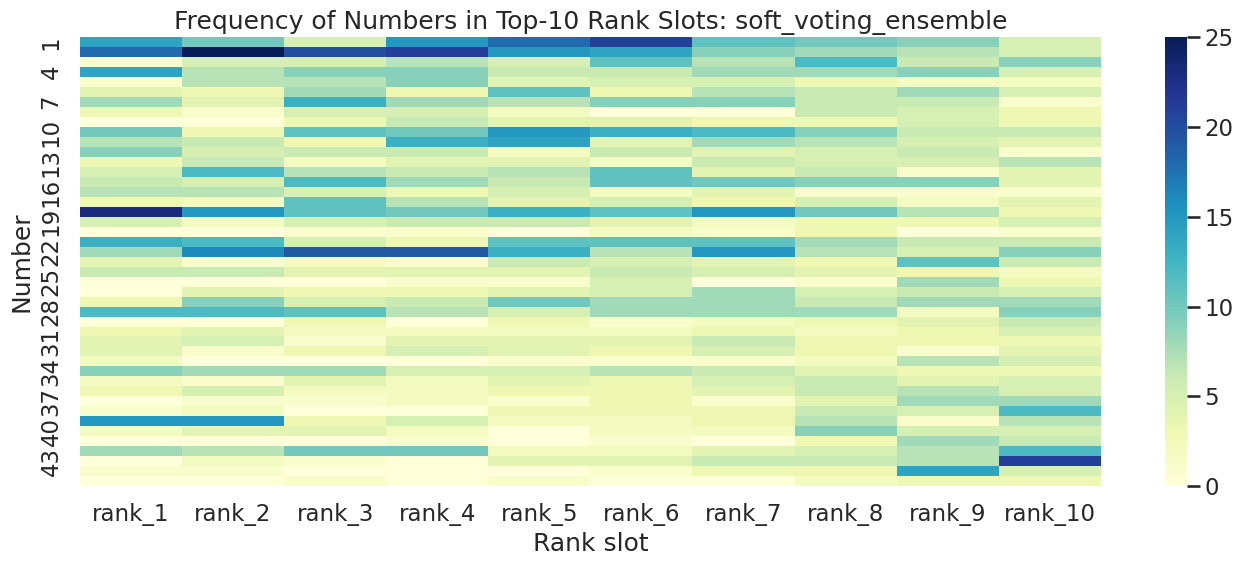

In [12]:
top_slots = rank_frequency.copy()
top_slots["rank_slot"] = pd.Categorical(top_slots["rank_slot"], categories=[f"rank_{i}" for i in range(1, 11)], ordered=True)
fig_rank_heatmap, ax = plt.subplots(figsize=(14, 6))
heatmap_df = top_slots.pivot(index="number", columns="rank_slot", values="count").fillna(0)
sns.heatmap(heatmap_df, cmap="YlGnBu", ax=ax)
ax.set_title(f"Frequency of Numbers in Top-10 Rank Slots: {model_name}")
ax.set_xlabel("Rank slot")
ax.set_ylabel("Number")
plt.tight_layout()
plt.show()

## Interpretation Notes

In [13]:
summary_frame = pd.DataFrame([{
    "feature_set": feature_set_name,
    "model": model_name,
    "training_regime": training_regime,
    "avg_hit": holdout_eval["avg_hit"],
    "precision_at_6": holdout_eval["precision_at_6"],
    "brier_score": holdout_eval["brier_score"],
    "mean_positive_probability": flat_probability_frame.loc[flat_probability_frame["actual"] == 1, "predicted_probability"].mean(),
    "mean_negative_probability": flat_probability_frame.loc[flat_probability_frame["actual"] == 0, "predicted_probability"].mean(),
}])
summary_frame

,feature_set,model,training_regime,avg_hit,precision_at_6,brier_score,mean_positive_probability,mean_negative_probability
0,full_feature_set,soft_voting_ensemble,last_500,0.863071,0.143845,0.19518,0.27735,0.268045


Read the diagnostics conservatively:

- a useful ranking model should assign, on average, higher probabilities to positive labels than to negative ones
- a flatter precision@k curve is okay, but it should still be clearly above the random 6/45 baseline near the top ranks
- calibration close to the diagonal is helpful, but in this problem ranking separation matters more than perfect probability calibration
- if the top-10 heatmap concentrates too heavily on a few numbers, the model may be overconfident rather than broadly informative

## Report Export

In [14]:
save_report_figure(fig_calibration, "fig_43_probability_ranking_calibration.png")
save_report_figure(fig_probability_density, "fig_44_probability_ranking_density.png")
save_report_figure(fig_precision_k, "fig_45_probability_ranking_precision_at_k.png")
save_report_figure(fig_rank_heatmap, "fig_46_probability_ranking_top10_heatmap.png")

save_report_table(summary_frame, "table_35_probability_ranking_summary.csv")
save_report_table(calibration_table, "table_36_probability_ranking_calibration_bins.csv")
save_report_table(precision_k_table, "table_37_probability_ranking_precision_at_k.csv")
save_report_table(rank_frequency, "table_38_probability_ranking_top10_frequency.csv")
print("Saved probability ranking analysis report artifacts.")

Saved probability ranking analysis report artifacts.
